In [1]:
from functools import partial

import numpy as np

from configs import DETECTOR, N_NUMBERS
from core import (
    calculate_auc_score,
    run_experiment,
    show_experiment,
)
from emulations import (
    emulate_peak_shape,
    emulate_spectrum,
    setup_emulation,
)
from estimators import (
    build_matched_filter,
    estimate_by_amplitude,
    estimate_by_integral,
    estimate_by_template,
)
from utils import (
    build_template,
)

POSITION = N_NUMBERS // 2
AMPLITUDE = 1/(2 ** np.linspace(10, 3, 28+1))

In [2]:
peak_shape = emulate_peak_shape(
    width=1.5,
    asymmetry=0,
    ratio=0.1,
)

In [3]:
template = build_template(
    peak_shape=peak_shape,
    number=np.linspace(0, N_NUMBERS, endpoint=False),
    position=POSITION,
)

In [8]:
estimators = {
    'amplitude': partial(estimate_by_amplitude, position=POSITION),
    'amplitude (matched filter)': partial(estimate_by_amplitude, position=POSITION, transformer=build_matched_filter(template[::-1])),
    # 'integral (1)': partial(estimate_by_integral, position=POSITION, interval=1),
    'integral (2)': partial(estimate_by_integral, position=POSITION, interval=2),
    # 'integral (3)': partial(estimate_by_integral, position=POSITION, interval=3),
}
fpr_intercept = [1e-1, 1e-2, 1e-3]
auc_scores, fprs, tprs = run_experiment(
    peak_shape=peak_shape,
    position=POSITION,
    amplitude=AMPLITUDE,
    estimators=estimators,
    fpr_intercept=fpr_intercept,
)

Estimators:   0%|          | 0/3 [00:00<?, ?it/s]

amplitude:   0%|          | 0/29 [00:00<?, ?it/s]

amplitude (matched filter):   0%|          | 0/29 [00:00<?, ?it/s]

integral (2):   0%|          | 0/29 [00:00<?, ?it/s]

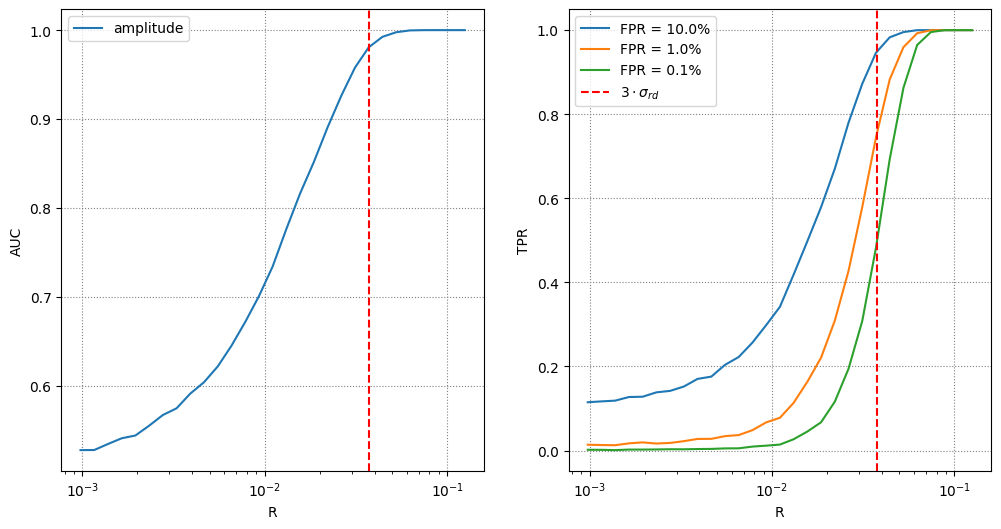

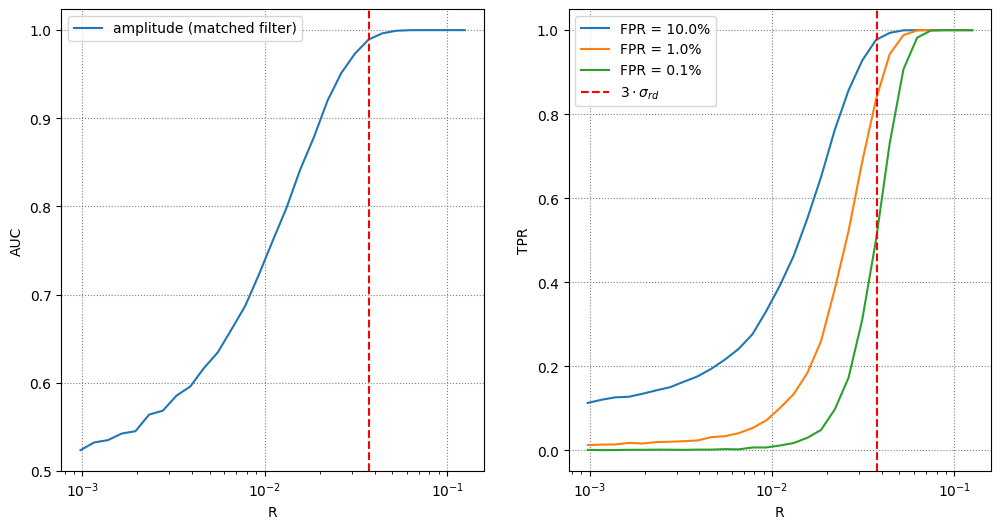

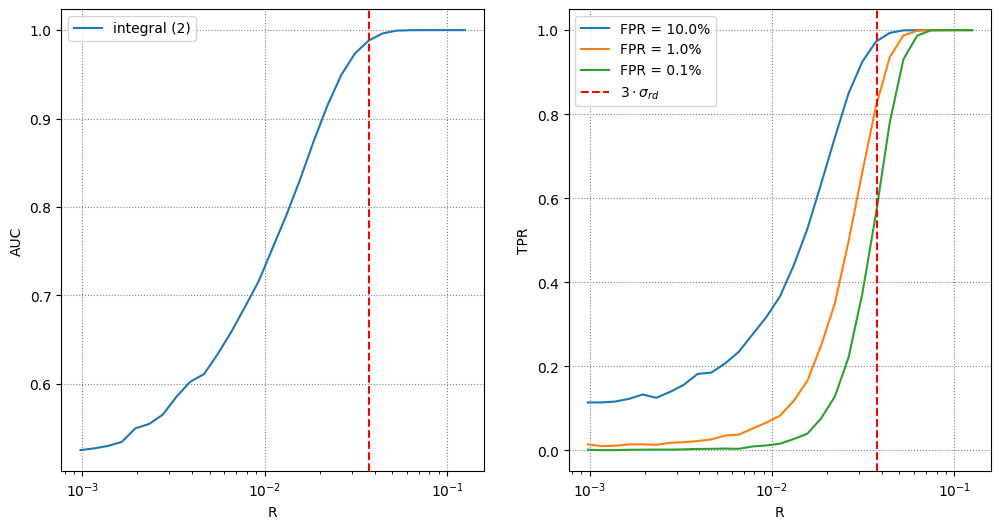

In [9]:
for key in [
    'amplitude',
    'amplitude (matched filter)',
    'integral (2)',
]:
    show_experiment(
        amplitude=AMPLITUDE,
        auc_score=auc_scores[key],
        fpr=fprs[key],
        tpr=tprs[key],
        label=key,
    )


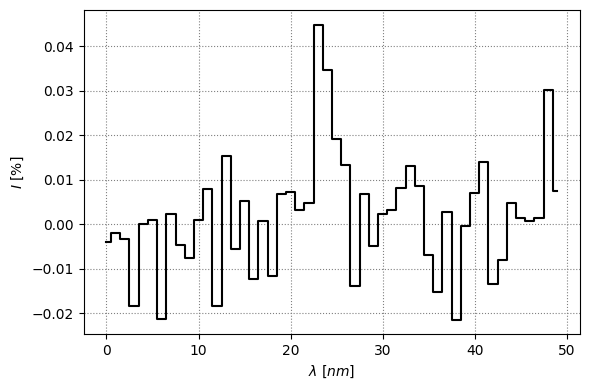

amplitude


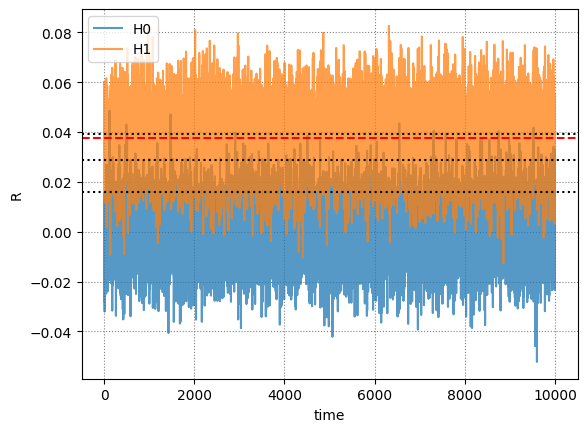

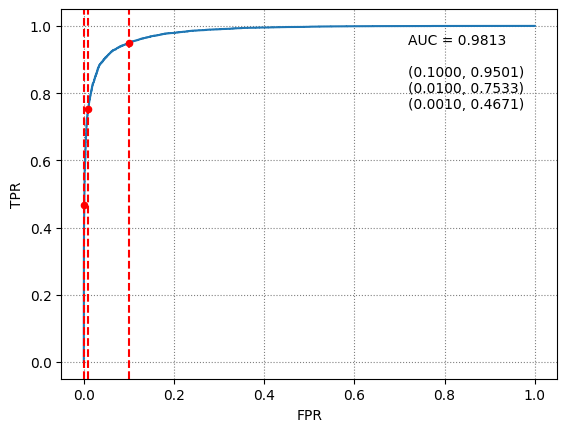

0.9812949300000001 [0.1   0.01  0.001] [0.9501 0.7533 0.4671] [0.01600848 0.02870653 0.03904084]
matched filter


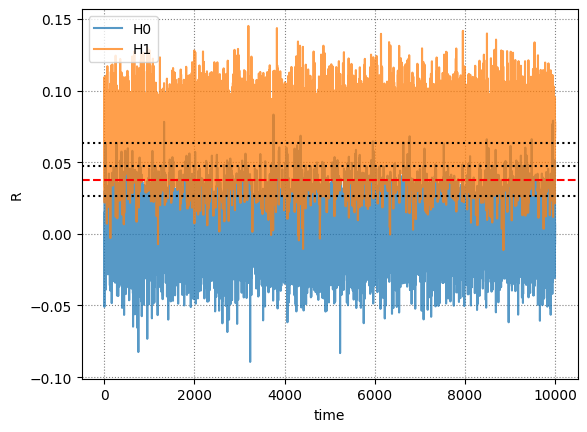

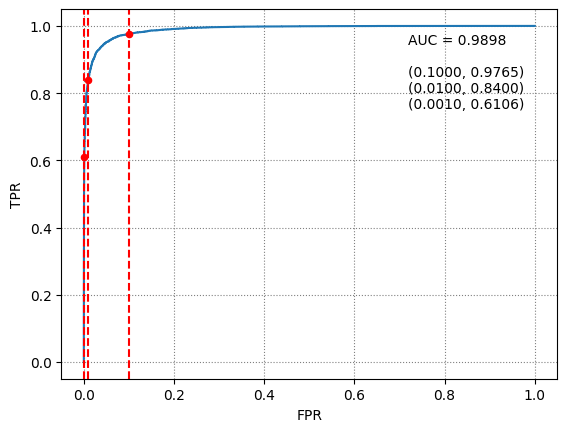

0.9897563499999998 [0.1   0.01  0.001] [0.9765 0.84   0.6106] [0.02628247 0.04748197 0.06312516]
integral (2)


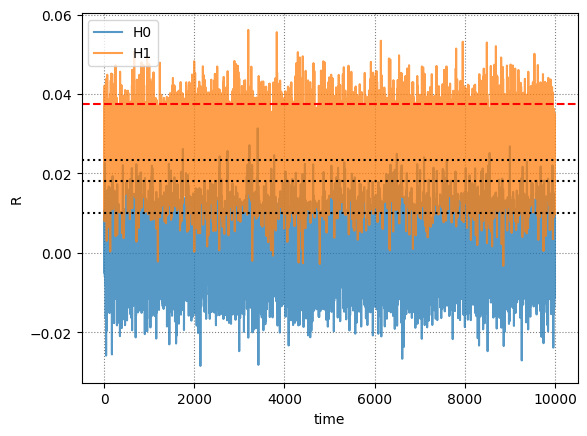

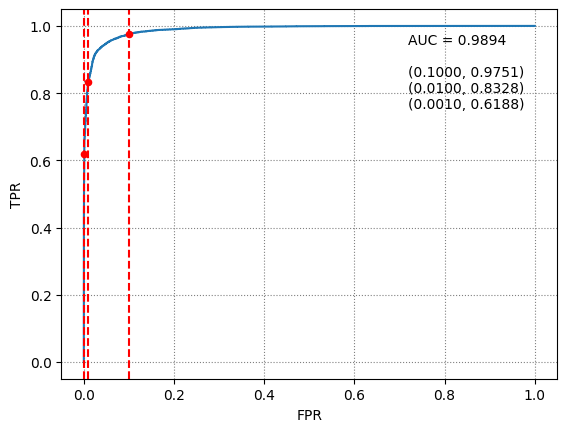

0.98939696 [0.1   0.01  0.001] [0.9751 0.8328 0.6188] [0.00997482 0.01803899 0.02339474]


In [10]:
noise_read = 100 * DETECTOR.config.read_noise / DETECTOR.config.capacity
amplitude = 3 * noise_read

emulation = setup_emulation(
    peak_shape=peak_shape,
)

spectrum = emulate_spectrum(
    emulation=emulation,
    position=POSITION,
    concentration=emulation.transform_amplitude_to_concentration(
        position=POSITION,
        amplitude=amplitude,
    ),
)
spectrum[0].show()

for label, estimator in [
    ('amplitude', partial(estimate_by_amplitude, position=POSITION)),
    # ('amplitude (matched filter)', partial(estimate_by_amplitude, position=POSITION, transformer=matched_filter)),
    ('matched filter', partial(estimate_by_template, template=template)),
    # ('integral (1)', partial(estimate_by_integral, position=POSITION, interval=1)),
    ('integral (2)', partial(estimate_by_integral, position=POSITION, interval=2)),
    # ('integral (3)', partial(estimate_by_integral, position=POSITION, interval=3)),
]:

    score_h0 = estimator(
        spectrum=emulate_spectrum(
            emulation=emulation,
            position=POSITION,
            concentration=0,
        ),
    )
    score_h1 = estimator(
        spectrum=spectrum,
    )

    print(label)

    auc_score, fpr, tpr, threshold = calculate_auc_score(
        score_h0=score_h0,
        score_h1=score_h1,
        fpr_intercept=[1e-1, 1e-2, 1e-3],
        show=True,
    )

    print(auc_score, fpr, tpr, threshold)
